# S5 Contrastive SSL Colab

This notebook builds a Colab-friendly S5 self-supervised learning baseline on Utah-array cache shards stored in Google Drive.

It supports two contrastive objectives behind one switch:

- `future_infonce`: CPC-style future-state InfoNCE over S5 hidden states.
- `augment_infonce`: same-window augmentation contrastive learning over pooled segment embeddings.

The notebook keeps the existing `s5_future_prediction.ipynb` data-loading pattern:

- mount Google Drive
- clone the public repo
- copy cache data to `/content`
- train from local disk
- save logs, checkpoints, and plots back to Drive


In [1]:
# Mount Drive and resolve cache / output roots.
from google.colab import drive
from pathlib import Path


drive.mount("/content/drive")

DRIVE_ROOT = Path("/content/drive/MyDrive")
cache_candidates = [
    DRIVE_ROOT / "utah_ssl" / "data" / "cache_v1",
    DRIVE_ROOT / "utah_ssl" / "data" / "cache_v1_fused",
    DRIVE_ROOT / "utah_ssl" / "data" / "v1_cache",
    DRIVE_ROOT / "utah_ssl" / "data" / "v1_cache_fused",
    DRIVE_ROOT / "cache_v1",
    DRIVE_ROOT / "cache_v1_fused",
    DRIVE_ROOT / "v1_cache",
    DRIVE_ROOT / "v1_cache_fused",
]
CACHE_ROOT = next((p for p in cache_candidates if p.exists()), cache_candidates[0])
OUTPUT_ROOT = DRIVE_ROOT / "utah_ssl" / "outputs" / "ssl_experiments" / "contrastive"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print("DRIVE_ROOT :", DRIVE_ROOT)
print("CACHE_ROOT :", CACHE_ROOT, "| exists:", CACHE_ROOT.exists())
print("OUTPUT_ROOT:", OUTPUT_ROOT, "| exists:", OUTPUT_ROOT.exists())

if CACHE_ROOT.exists():
    datasets = sorted(p.name for p in CACHE_ROOT.iterdir() if p.is_dir())
    print("datasets:", datasets)
else:
    print("cache candidates checked:")
    for path in cache_candidates:
        print(" -", path)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DRIVE_ROOT : /content/drive/MyDrive
CACHE_ROOT : /content/drive/MyDrive/utah_ssl/data/cache_v1 | exists: True
OUTPUT_ROOT: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/contrastive | exists: True
datasets: ['000950', 'brain2text24', 'brain2text25', 'motor_data', 'plug_n_play', 'unsupervised_cursor_recalibration_offline', 'unsupervised_cursor_recalibration_online', 'willett_handwriting']


In [2]:
# Clone the public repo and import the reusable contrastive SSL helpers.
import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/ethan-read/utah-ssl.git"
REPO_DIR = Path("/content/utah-ssl")
EXPERIMENTS_DIR = REPO_DIR / "analysis" / "active" / "ssl_experiments"
CONTRASTIVE_SSL_DIR = EXPERIMENTS_DIR / "contrastive_ssl"
SSL_DIR = REPO_DIR / "analysis" / "active" / "transfer_benchmark" / "ssl_autoresearch"

if REPO_DIR.exists():
    print("Using existing repo:", REPO_DIR)
    subprocess.run(["git", "-C", str(REPO_DIR), "fetch", "origin"], check=True)
    subprocess.run(["git", "-C", str(REPO_DIR), "pull", "--ff-only", "origin", "main"], check=True)
else:
    subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)

os.chdir(REPO_DIR)

for candidate in (REPO_DIR, EXPERIMENTS_DIR, SSL_DIR):
    candidate_str = str(candidate)
    if candidate_str not in sys.path:
        sys.path.insert(0, candidate_str)

os.environ["SSL_AUTORESEARCH_CACHE_ROOT"] = str(CACHE_ROOT)
os.environ["SSL_AUTORESEARCH_OUTPUT_ROOT"] = str(OUTPUT_ROOT)

if not CONTRASTIVE_SSL_DIR.exists():
    raise FileNotFoundError(
        "The cloned repo does not contain analysis/active/ssl_experiments/contrastive_ssl. "
        "If you are running this notebook from Colab, make sure REPO_DIR points at a repo checkout that includes the refactor."
    )

from contrastive_ssl import (
    CacheAccessConfig,
    DownstreamProbeConfig,
    SSLTrainingConfig,
    build_random_init_probe_state,
    build_segment_sampler,
    plot_ssl_training_history,
    prepare_cache_context,
    recover_downstream_probe_state,
    run_downstream_probe,
    run_probe_head_sweep,
    run_ssl_training,
)

print("cwd:", Path.cwd())
print("repo dir exists:", REPO_DIR.exists(), REPO_DIR)
print("experiments dir exists:", EXPERIMENTS_DIR.exists(), EXPERIMENTS_DIR)
print("contrastive_ssl dir exists:", CONTRASTIVE_SSL_DIR.exists(), CONTRASTIVE_SSL_DIR)
print("ssl dir exists:", SSL_DIR.exists(), SSL_DIR)
print("SSL_AUTORESEARCH_CACHE_ROOT:", os.environ["SSL_AUTORESEARCH_CACHE_ROOT"])
print("SSL_AUTORESEARCH_OUTPUT_ROOT:", os.environ["SSL_AUTORESEARCH_OUTPUT_ROOT"])


Using existing repo: /content/utah-ssl
cwd: /content/utah-ssl
ssl dir exists: True /content/utah-ssl/analysis/active/transfer_benchmark/ssl_autoresearch
benchmark split helper status: {'split_latest_sessions': 'split_latest_sessions', 'session_ids_from_cache_split': 'session_ids_from_cache_split'}
SSL_AUTORESEARCH_CACHE_ROOT: /content/drive/MyDrive/utah_ssl/data/cache_v1
SSL_AUTORESEARCH_OUTPUT_ROOT: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/contrastive


In [3]:
# Experiment config.
SEED = 7
OBJECTIVE_MODE = "future_infonce"
SEGMENT_BINS = 64
FUTURE_HORIZONS = (1, 3)
PATCH_SIZE = 1
PATCH_STRIDE = 1
HIDDEN_SIZE = 128
S5_STATE_SIZE = 64
NUM_LAYERS = 1
DROPOUT = 0.1
BATCH_SIZE = 32
NUM_STEPS = 500
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-2
TEMPERATURE = 0.1
VAL_EVERY = 50
VAL_BATCHES = 10
DATASET_WEIGHT_ALPHA = 0.25
EXAMPLES_PER_SHARD = 8
POST_PROJ_NORM = "rms"
CACHE_ACCESS_MODE = "copy_to_local"
# CACHE_ACCESS_MODE = "drive_direct"

LOCAL_CACHE_BASE = "/content/utah_ssl_cache"
FORCE_RECOPY_LOCAL_CACHE = False
EXCLUDED_DATASETS = {"brain2text25"}
LOG_EVERY = 10
NORMALIZE_IMPL_VERSION = "segment_prefix_v1"
NORMALIZE_CONTEXT_BINS = min(16, SEGMENT_BINS)

AUGMENT_CFG = {
    "noise_std": 0.01,
    "scale_jitter": 0.05,
    "offset_jitter": 0.05,
    "time_mask_frac": 0.10,
    "channel_dropout_prob": 0.05,
    "clip_value": 20.0,
}

CACHE_ACCESS_CONFIG = CacheAccessConfig(
    mode=CACHE_ACCESS_MODE,
    local_cache_base=LOCAL_CACHE_BASE,
    force_recopy_local_cache=FORCE_RECOPY_LOCAL_CACHE,
    excluded_datasets=tuple(sorted(EXCLUDED_DATASETS)),
    seed=SEED,
    segment_bins=SEGMENT_BINS,
    normalize_context_bins=NORMALIZE_CONTEXT_BINS,
    normalize_impl_version=NORMALIZE_IMPL_VERSION,
    examples_per_shard=EXAMPLES_PER_SHARD,
)
SSL_TRAINING_CONFIG = SSLTrainingConfig(
    seed=SEED,
    objective_mode=OBJECTIVE_MODE,
    segment_bins=SEGMENT_BINS,
    future_horizons=FUTURE_HORIZONS,
    patch_size=PATCH_SIZE,
    patch_stride=PATCH_STRIDE,
    hidden_size=HIDDEN_SIZE,
    s5_state_size=S5_STATE_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    batch_size=BATCH_SIZE,
    num_steps=NUM_STEPS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    temperature=TEMPERATURE,
    val_every=VAL_EVERY,
    val_batches=VAL_BATCHES,
    dataset_weight_alpha=DATASET_WEIGHT_ALPHA,
    examples_per_shard=EXAMPLES_PER_SHARD,
    log_every=LOG_EVERY,
    post_proj_norm=POST_PROJ_NORM,
    augment_cfg=dict(AUGMENT_CFG),
)

print("CACHE_ACCESS_CONFIG:", CACHE_ACCESS_CONFIG)
print("SSL_TRAINING_CONFIG:", SSL_TRAINING_CONFIG)


OBJECTIVE_MODE: future_infonce
SEGMENT_BINS: 64
FUTURE_HORIZONS: (1, 3)
PATCH: (1, 1)
MODEL: {'hidden_size': 128, 's5_state_size': 64, 'num_layers': 1, 'dropout': 0.1}
TRAIN: {'batch_size': 32, 'num_steps': 500, 'lr': 0.0003, 'weight_decay': 0.01, 'temperature': 0.1}
VAL: {'val_every': 50, 'val_batches': 10}
CACHE: {'access_mode': 'copy_to_local', 'local_cache_base': '/content/utah_ssl_cache', 'force_recopy': False}
AUGMENT_CFG: {'noise_std': 0.01, 'scale_jitter': 0.05, 'offset_jitter': 0.05, 'time_mask_frac': 0.1, 'channel_dropout_prob': 0.05, 'clip_value': 20.0}


In [4]:
# Resolve cache access mode, summarize datasets, and build the reusable cache context.
import os

CACHE_CONTEXT = prepare_cache_context(
    cache_candidates=cache_candidates,
    config=CACHE_ACCESS_CONFIG,
)

DRIVE_CACHE_ROOT = CACHE_CONTEXT.drive_cache_root
CACHE_ROOT = CACHE_CONTEXT.cache_root
ACTIVE_CACHE_ROOT = CACHE_CONTEXT.cache_root
CACHE_COPY_USED = CACHE_CONTEXT.cache_copy_used
SOURCE_CACHE_SIGNATURE = CACHE_CONTEXT.source_cache_signature
available_datasets = CACHE_CONTEXT.available_datasets
pretrain_datasets = CACHE_CONTEXT.pretrain_datasets
session_split_summary = CACHE_CONTEXT.session_split_summary
SHARD_STORE = CACHE_CONTEXT.shard_store
SHARD_CACHE_RAM_GB = SHARD_STORE.summary()["budget_gb"]
HAS_VAL_DATASETS = CACHE_CONTEXT.has_val_datasets
TX_DIM = CACHE_CONTEXT.tx_dim
SBP_DIM = CACHE_CONTEXT.sbp_dim
FULL_DIM = CACHE_CONTEXT.full_dim
NORMALIZE_IMPL_VERSION = CACHE_CONTEXT.normalize_impl_version
NORMALIZE_CONTEXT_BINS = CACHE_CONTEXT.normalize_context_bins

os.environ["SSL_AUTORESEARCH_CACHE_ROOT"] = str(CACHE_ROOT)

print("CACHE_ACCESS_MODE:", CACHE_ACCESS_CONFIG.mode)
print("CACHE_COPY_USED:", CACHE_COPY_USED)
print("ACTIVE_CACHE_ROOT:", CACHE_ROOT)
print("NORMALIZE_IMPL_VERSION:", NORMALIZE_IMPL_VERSION)
print("NORMALIZE_CONTEXT_BINS:", NORMALIZE_CONTEXT_BINS)
print("SHARD_CACHE_RAM_GB:", SHARD_CACHE_RAM_GB)
print("available datasets:")
for name in available_datasets:
    tag = "excluded" if name in EXCLUDED_DATASETS else "included"
    print(f" - {name} [{tag}]")
print("session split summary:")
for dataset in pretrain_datasets:
    summary = session_split_summary[dataset]
    print(
        f" - {dataset}: sessions={summary['total_sessions']} train_sessions={summary['train_sessions']} "
        f"val_sessions={summary['val_sessions']} train_examples={summary['train_examples']} "
        f"val_examples={summary['val_examples']} val_eligible={summary['val_eligible']}"
    )
print("shard cache:", SHARD_STORE.summary())


using existing local cache: /content/utah_ssl_cache/cache_v1
source signature: 875d5322885b
CACHE_ACCESS_MODE: copy_to_local
CACHE_COPY_USED: True
ACTIVE_CACHE_ROOT: /content/utah_ssl_cache/cache_v1
available datasets:
 - 000950 [included]
 - brain2text24 [included]
 - brain2text25 [excluded]
 - motor_data [included]
 - plug_n_play [included]
 - unsupervised_cursor_recalibration_offline [included]
 - unsupervised_cursor_recalibration_online [included]
 - willett_handwriting [included]

pretrain datasets: ['000950', 'brain2text24', 'motor_data', 'plug_n_play', 'unsupervised_cursor_recalibration_offline', 'unsupervised_cursor_recalibration_online', 'willett_handwriting']
NORMALIZE_IMPL_VERSION: segment_prefix_v1
NORMALIZE_CONTEXT_BINS: 16
SHARD_CACHE_RAM_GB: 3.29

session split summary:
 - 000950: sessions=47 train_sessions=37 val_sessions=10 train_examples=569 val_examples=159 val_eligible=True
 - brain2text24: sessions=28 train_sessions=22 val_sessions=6 train_examples=12811 val_exampl

In [5]:
# Sampler smoke test.
from collections import Counter

INSPECT_BATCH_SIZE = 8
inspect_train_sampler = build_segment_sampler(
    CACHE_CONTEXT,
    "train",
    batch_size=INSPECT_BATCH_SIZE,
    seed=SEED,
    segment_bins=SEGMENT_BINS,
    dataset_weight_alpha=DATASET_WEIGHT_ALPHA,
    examples_per_shard=EXAMPLES_PER_SHARD,
)
inspect_batch = inspect_train_sampler.sample_batch()

print("train batch shapes:")
print(" - x           :", tuple(inspect_batch["x"].shape))
print(" - feature_mask:", tuple(inspect_batch["feature_mask"].shape))
print(" - lengths     :", tuple(inspect_batch["lengths"].shape))
print(" - dataset mix :", Counter(inspect_batch["datasets"]))
print(" - session keys:", inspect_batch["session_keys"][:3])

if HAS_VAL_DATASETS:
    inspect_val_sampler = build_segment_sampler(
        CACHE_CONTEXT,
        "val",
        batch_size=min(INSPECT_BATCH_SIZE, 4),
        seed=SEED + 1,
        segment_bins=SEGMENT_BINS,
        dataset_weight_alpha=DATASET_WEIGHT_ALPHA,
        examples_per_shard=EXAMPLES_PER_SHARD,
    )
    inspect_val_batch = inspect_val_sampler.sample_batch()
    print("\nval batch shapes:")
    print(" - x           :", tuple(inspect_val_batch["x"].shape))
    print(" - feature_mask:", tuple(inspect_val_batch["feature_mask"].shape))
    print(" - lengths     :", tuple(inspect_val_batch["lengths"].shape))
    print(" - dataset mix :", Counter(inspect_val_batch["datasets"]))
else:
    print("\nNo validation sampler was built because all datasets are single-session.")


train batch shapes:
 - x           : (8, 64, 512)
 - feature_mask: (8, 512)
 - lengths     : (8,)
 - dataset mix : Counter({'willett_handwriting': 2, 'unsupervised_cursor_recalibration_online': 2, '000950': 1, 'unsupervised_cursor_recalibration_offline': 1, 'motor_data': 1, 'brain2text24': 1})
 - session keys: ['000950:sub-T5-held-in-calib_ses-20220525', 'unsupervised_cursor_recalibration_offline:t5.2019.04.01', 'willett_handwriting:t5.2019.05.08']

val batch shapes:
 - x           : (4, 64, 512)
 - feature_mask: (4, 512)
 - lengths     : (4,)
 - dataset mix : Counter({'motor_data': 2, 'willett_handwriting': 1, 'unsupervised_cursor_recalibration_online': 1})


In [6]:
# Runtime summary.
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)
print("FULL_DIM:", FULL_DIM)
print("pretrain_datasets:", pretrain_datasets)
print("HAS_VAL_DATASETS:", HAS_VAL_DATASETS)


DEVICE: cuda
smoke_mode=future_infonce
 - loss: 6.463848114013672
 - top1: 0.0050578974187374115
 - positive_pairs: 992
 - grad_norm: 2.4977762699127197
 - per_horizon_losses: {1: 6.453948974609375, 3: 6.4737467765808105}
 - per_horizon_top1: {1: 0.003968254197388887, 3: 0.006147540640085936}
smoke_mode=augment_infonce
 - loss: 0.10885816812515259
 - top1: 1.0
 - positive_pairs: 8
 - grad_norm: 2.7086212635040283
 - mean_abs_view_delta: 0.1182774230837822

Default run mode: future_infonce


In [7]:
# Run the selected contrastive SSL objective.
SSL_RUN_STATE = run_ssl_training(
    cache_context=CACHE_CONTEXT,
    config=SSL_TRAINING_CONFIG,
    output_root=OUTPUT_ROOT,
    device=DEVICE,
)

# Backward-compatible globals for downstream cells.
model = SSL_RUN_STATE["model"]
optimizer = SSL_RUN_STATE["optimizer"]
TRAIN_SAMPLER = SSL_RUN_STATE["train_sampler"]
VAL_SAMPLER = SSL_RUN_STATE["val_sampler"]
run_name = SSL_RUN_STATE["run_name"]
run_dir = SSL_RUN_STATE["run_dir"]
progress_path = SSL_RUN_STATE["progress_path"]
checkpoint_path = SSL_RUN_STATE["checkpoint_path"]
plot_loss_path = SSL_RUN_STATE["plot_loss_path"]
plot_top1_path = SSL_RUN_STATE["plot_top1_path"]
config = SSL_RUN_STATE["config"]
best_score = SSL_RUN_STATE["best_score"]
train_history = SSL_RUN_STATE["train_history"]
val_history = SSL_RUN_STATE["val_history"]

print("SSL_RUN_STATE ready:", run_dir)


step=001 train_loss=7.9443 train_top1=0.0008 grad_norm=1.6778 sample_s=3.76 model_s=0.08
step=010 train_loss=7.6438 train_top1=0.0013 grad_norm=1.2320 sample_s=3.79 model_s=0.08
step=020 train_loss=7.4148 train_top1=0.0043 grad_norm=1.1210 sample_s=4.04 model_s=0.12
step=030 train_loss=7.1813 train_top1=0.0063 grad_norm=1.3015 sample_s=2.84 model_s=0.13
step=040 train_loss=6.9620 train_top1=0.0065 grad_norm=1.3733 sample_s=2.53 model_s=0.08
step=050 train_loss=6.7113 train_top1=0.0110 grad_norm=1.3913 sample_s=0.60 model_s=0.08
step=050 val_loss=6.6702 val_top1=0.0100 positive_pairs=39680
step=060 train_loss=6.3859 train_top1=0.0128 grad_norm=1.5403 sample_s=0.32 model_s=0.08
step=070 train_loss=6.0383 train_top1=0.0168 grad_norm=1.4870 sample_s=0.49 model_s=0.08
step=080 train_loss=5.6749 train_top1=0.0296 grad_norm=1.5758 sample_s=1.64 model_s=0.10
step=090 train_loss=5.2542 train_top1=0.0392 grad_norm=1.5980 sample_s=1.77 model_s=0.08
step=100 train_loss=5.1115 train_top1=0.0588 gra

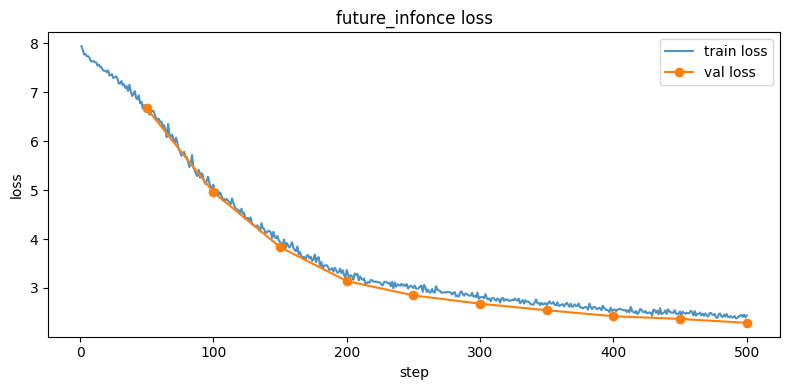

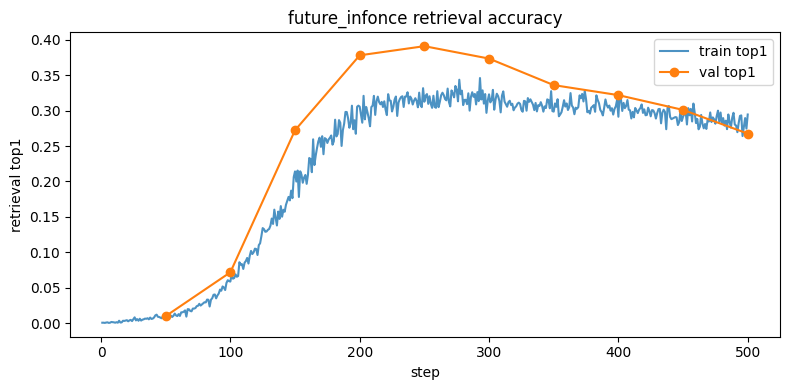

train_start_loss: 7.944299221038818
train_final_loss: 2.437744617462158
train_best_loss: 2.3754677772521973 at step 492
train_final_top1: 0.2944720983505249
val_best_loss: 2.2842838764190674 at step 500
val_best_top1: 0.3908689618110657 at step 250
plot_loss_path: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/contrastive/colab_s5_future_infonce_seg64_20260405T123038Z/loss_curve.png
plot_top1_path: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/contrastive/colab_s5_future_infonce_seg64_20260405T123038Z/retrieval_curve.png


In [ ]:
# Plot training curves for the latest SSL run.
if "SSL_RUN_STATE" not in globals():
    raise RuntimeError("Run the SSL training cell first so SSL_RUN_STATE is defined.")

SSL_PLOT_STATE = plot_ssl_training_history(SSL_RUN_STATE)


## Benchmark-lite Downstream Phoneme Probe

This section runs a cheap held-out Brain2Text25 causal phoneme probe on the current SSL encoder.
It follows the staged BIT logic: evaluate encoder quality with phoneme CTC before any sentence-level decoding.


In [ ]:
# Benchmark-lite downstream phoneme probe config.
DOWNSTREAM_PROBE_CONFIG = DownstreamProbeConfig(
    enabled=True,
    seed=SEED,
    comparison_mode="ssl_only",
    session_limit=4,
    target_session_count=1,
    adaptation_regime="A",
    probe_batch_size=8,
    probe_budget_seconds=240,
    max_probe_steps=400,
    progress_every_steps=25,
    progress_every_seconds=15.0,
    probe_head_type="linear",
    probe_lstm_hidden_size=64,
    probe_conv_hidden_size=128,
    probe_conv_kernel_size=3,
    checkpoint_source="most_recent_valid_then_in_memory",
)
DOWNSTREAM_PROBE_SUMMARY_BASENAME = DOWNSTREAM_PROBE_CONFIG.summary_basename

print("DOWNSTREAM_PROBE_CONFIG:", DOWNSTREAM_PROBE_CONFIG)


DOWNSTREAM_PROBE_CONFIG:
 - enabled: True
 - comparison_mode: ssl_only
 - session_limit: 4
 - target_session_count: 1
 - adaptation_regime: A
 - probe_batch_size: 8
 - probe_budget_seconds: 240
 - max_probe_steps: 400
 - progress_every_steps: 25
 - checkpoint_source: preferred_checkpoint_then_in_memory
 - preferred_num_steps: 500
 - preferred_objective_mode: future_infonce
 - progress_every_seconds: 15.0
 - summary_basename: downstream_probe_summary.json


In [ ]:
# Import and validate benchmark-lite downstream probe helpers from the current repo checkout.
from pathlib import Path

from contrastive_ssl.probe import build_downstream_probe_problem

CANONICAL_B2T25_ROOT = Path(CACHE_ROOT) / "brain2text25"
CANONICAL_B2T25_MANIFEST_PATH = CANONICAL_B2T25_ROOT / "manifest.jsonl"
CANONICAL_B2T25_METADATA_PATH = CANONICAL_B2T25_ROOT / "metadata.json"

if not CANONICAL_B2T25_MANIFEST_PATH.exists() or not CANONICAL_B2T25_METADATA_PATH.exists():
    raise FileNotFoundError(
        "Canonical Brain2Text25 cache manifest / metadata is missing from the mounted cache. "
        f"Expected {CANONICAL_B2T25_MANIFEST_PATH} and {CANONICAL_B2T25_METADATA_PATH}."
    )

downstream_probe_problem_preview = build_downstream_probe_problem(
    cache_root=Path(CACHE_ROOT),
    probe_config=DOWNSTREAM_PROBE_CONFIG,
)
downstream_probe_metadata_preview = downstream_probe_problem_preview["metadata"]

if "phoneme_vocabulary" not in downstream_probe_metadata_preview:
    raise KeyError("Canonical Brain2Text25 metadata is missing 'phoneme_vocabulary'.")

downstream_probe_eligible_entries = downstream_probe_problem_preview["eligible_entries"]
downstream_probe_split_preview = downstream_probe_problem_preview["split"]

print("BENCHMARK_HELPER_SOURCE:", "contrastive_ssl_package")
print("Canonical Brain2Text25 probe assets:")
print(" - root:", CANONICAL_B2T25_ROOT)
print(" - manifest:", CANONICAL_B2T25_MANIFEST_PATH)
print(" - metadata:", CANONICAL_B2T25_METADATA_PATH)
print(" - eligible_sessions:", len(downstream_probe_eligible_entries))
print(" - preview_source_sessions:", [entry.session_base for entry in downstream_probe_split_preview.train])
print(" - preview_target_sessions:", [entry.session_base for entry in downstream_probe_split_preview.val])


BENCHMARK_HELPER_SOURCE: notebook_fallback (ImportError: Benchmark helpers missing from repo checkout: data=['load_b2t25_canonical_inventory', 'CanonicalSequenceDataset'] train=ok)
Canonical Brain2Text25 probe assets:
 - root: /content/utah_ssl_cache/cache_v1/brain2text25
 - manifest: /content/utah_ssl_cache/cache_v1/brain2text25/manifest.jsonl
 - metadata: /content/utah_ssl_cache/cache_v1/brain2text25/metadata.json
 - eligible_sessions: 45
 - preview_source_sessions: ['t15.2025.03.14', 't15.2025.03.16', 't15.2025.03.30']
 - preview_target_sessions: ['t15.2025.04.13']


In [ ]:
# Recover the default SSL encoder and prepare reusable downstream probe state.
DOWNSTREAM_PROBE_DEFAULT_STATE = recover_downstream_probe_state(
    probe_config=DOWNSTREAM_PROBE_CONFIG,
    output_root=OUTPUT_ROOT,
    input_dim=FULL_DIM,
    default_checkpoint_config=SSL_TRAINING_CONFIG.checkpoint_config(),
    in_memory_model=SSL_RUN_STATE["model"] if "SSL_RUN_STATE" in globals() else None,
    current_checkpoint_path=Path(checkpoint_path) if "checkpoint_path" in globals() else None,
    current_run_dir=Path(run_dir) if "run_dir" in globals() else None,
)
DOWNSTREAM_PROBE_BASE_RUN_DIR = Path(DOWNSTREAM_PROBE_DEFAULT_STATE["base_run_dir"])
DOWNSTREAM_PROBE_RUN_DIR = DOWNSTREAM_PROBE_BASE_RUN_DIR
DOWNSTREAM_PROBE_CHECKPOINT_PATH = DOWNSTREAM_PROBE_DEFAULT_STATE["checkpoint_path"]
DOWNSTREAM_PROBE_CHECKPOINT_CONFIG = dict(DOWNSTREAM_PROBE_DEFAULT_STATE["checkpoint_config"])
DOWNSTREAM_PROBE_ENCODER_SOURCE = str(DOWNSTREAM_PROBE_DEFAULT_STATE["source"])
DOWNSTREAM_PROBE_ENCODER = DOWNSTREAM_PROBE_DEFAULT_STATE["encoder"]

print("DOWNSTREAM_PROBE_ENCODER_SOURCE:", DOWNSTREAM_PROBE_ENCODER_SOURCE)
print("DOWNSTREAM_PROBE_BASE_RUN_DIR:", DOWNSTREAM_PROBE_BASE_RUN_DIR)
print("DOWNSTREAM_PROBE_CHECKPOINT_PATH:", DOWNSTREAM_PROBE_CHECKPOINT_PATH)
print("DOWNSTREAM_PROBE_CHECKPOINT_SELECTION:", DOWNSTREAM_PROBE_CONFIG.checkpoint_source)
print("DOWNSTREAM_PROBE_ENCODER:", DOWNSTREAM_PROBE_ENCODER)


DOWNSTREAM_PROBE_ENCODER_SOURCE: checkpoint
DOWNSTREAM_PROBE_BASE_RUN_DIR: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/contrastive/colab_s5_future_infonce_seg64_20260405T123038Z
DOWNSTREAM_PROBE_CHECKPOINT_PATH: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/contrastive/colab_s5_future_infonce_seg64_20260405T123038Z/checkpoint_final.pt
DOWNSTREAM_PROBE_PREFERRED_NUM_STEPS: 500
DOWNSTREAM_PROBE_PREFERRED_OBJECTIVE_MODE: future_infonce
DOWNSTREAM_PROBE_TARGET_SESSION: t15.2025.04.13
DOWNSTREAM_PROBE_ENCODER: NotebookProbeEncoderAdapter(
  (encoder): S5ContrastiveEncoder(
    (proj): Linear(in_features=512, out_features=128, bias=True)
    (post_proj_norm): RMSNorm()
    (backbone): S5SequenceBackbone(
      (blocks): ModuleList(
        (0): S5Block(
          (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (ssm): DiagonalS5SSM(
            (D): Linear(in_features=128, out_features=128, bias=False)
          )
          (dropout1): Dropout(p=

In [ ]:
# Run the held-out Brain2Text25 probe using the SSL checkpoint encoder.
import pandas as pd

SSL_PROBE_SUMMARY = run_downstream_probe(
    probe_state=DOWNSTREAM_PROBE_DEFAULT_STATE,
    probe_config=DOWNSTREAM_PROBE_CONFIG,
    cache_root=CACHE_ROOT,
    device=DEVICE,
    variant_prefix="ssl_checkpoint",
    artifact_prefix="ssl_probe",
    train_encoder=False,
    comparison_mode="ssl_only",
)

downstream_probe_summary = SSL_PROBE_SUMMARY
downstream_probe_summary_path = Path(SSL_PROBE_SUMMARY["summary_path"])
downstream_probe_progress_path = Path(SSL_PROBE_SUMMARY["progress_log_path"])

display(pd.DataFrame([SSL_PROBE_SUMMARY]))
print("downstream_probe_summary_path:", downstream_probe_summary_path)
print("downstream_probe_progress_path:", downstream_probe_progress_path)
if SSL_PROBE_SUMMARY.get("alignment_stats_path") is not None:
    print("downstream_probe_alignment_stats_path:", SSL_PROBE_SUMMARY["alignment_stats_path"])


,model_variant,comparison_mode,train_encoder,adaptation_regime,session_limit,target_session_count,heldout_target_session_id,source_session_ids,target_session_ids,selected_session_bases,...,top_substitution_pair,top_substitution_pair_rate,probe_steps,probe_elapsed_seconds,checkpoint_source_used,checkpoint_path,run_dir,progress_log_path,alignment_stats_path,summary_path
0,ssl_checkpoint_linear_probe,ssl_only,False,A,4,1,t15.2025.04.13,"[t15.2025.03.14, t15.2025.03.16, t15.2025.03.30]",[t15.2025.04.13],"[t15.2025.03.14, t15.2025.03.16, t15.2025.03.3...",...,T->SIL,0.075949,400,136.288254,checkpoint,/content/drive/MyDrive/utah_ssl/outputs/ssl_ex...,/content/drive/MyDrive/utah_ssl/outputs/ssl_ex...,/content/drive/MyDrive/utah_ssl/outputs/ssl_ex...,/content/drive/MyDrive/utah_ssl/outputs/ssl_ex...,/content/drive/MyDrive/utah_ssl/outputs/ssl_ex...


downstream_probe_summary_path: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/contrastive/colab_s5_future_infonce_seg64_20260405T123038Z/ssl_probe/downstream_probe_summary.json
downstream_probe_progress_path: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/contrastive/colab_s5_future_infonce_seg64_20260405T123038Z/ssl_probe/progress.jsonl
downstream_probe_alignment_stats_path: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/contrastive/colab_s5_future_infonce_seg64_20260405T123038Z/ssl_probe/val_alignment_stats.json


## Random-Init Comparison
Run the same held-out downstream probe starting from a fresh random `S5` encoder with the encoder frozen, so only the chosen `CTC` head is trained.


In [ ]:
# Run a random-init frozen probe baseline on the same held-out session.
import pandas as pd

RANDOM_INIT_LINEAR_PROBE_STATE = build_random_init_probe_state(
    reference_config=DOWNSTREAM_PROBE_DEFAULT_STATE["checkpoint_config"],
    input_dim=FULL_DIM,
    seed=SEED,
    base_run_dir=DOWNSTREAM_PROBE_BASE_RUN_DIR,
)
RANDOM_INIT_LINEAR_PROBE_SUMMARY = run_downstream_probe(
    probe_state=RANDOM_INIT_LINEAR_PROBE_STATE,
    probe_config=DOWNSTREAM_PROBE_CONFIG,
    cache_root=CACHE_ROOT,
    device=DEVICE,
    variant_prefix="random_init",
    artifact_prefix="random_init",
    train_encoder=False,
)

comparison_rows = []
if "SSL_PROBE_SUMMARY" in globals():
    comparison_rows.append(SSL_PROBE_SUMMARY)
comparison_rows.append(RANDOM_INIT_LINEAR_PROBE_SUMMARY)
comparison_df = pd.DataFrame(comparison_rows)
comparison_columns = [
    "model_variant",
    "probe_head_type",
    "probe_head_num_parameters",
    "train_encoder",
    "heldout_target_session_id",
    "target_train_examples",
    "target_val_examples",
    "val_ctc_bpphone",
    "val_phoneme_error_rate",
    "most_common_prediction",
    "most_common_prediction_rate",
    "most_common_false_prediction",
    "most_common_false_prediction_rate",
    "top_substitution_pair",
    "probe_steps",
    "probe_elapsed_seconds",
    "checkpoint_source_used",
]

display(comparison_df[comparison_columns])
print("random_init_probe_summary_path:", RANDOM_INIT_LINEAR_PROBE_SUMMARY["summary_path"])
print("random_init_probe_progress_path:", RANDOM_INIT_LINEAR_PROBE_SUMMARY["progress_log_path"])
if RANDOM_INIT_LINEAR_PROBE_SUMMARY.get("alignment_stats_path") is not None:
    print("random_init_probe_alignment_stats_path:", RANDOM_INIT_LINEAR_PROBE_SUMMARY["alignment_stats_path"])


,model_variant,train_encoder,heldout_target_session_id,target_train_examples,target_val_examples,val_ctc_bpphone,val_phoneme_error_rate,most_common_prediction,most_common_prediction_rate,most_common_false_prediction,most_common_false_prediction_rate,top_substitution_pair,probe_steps,probe_elapsed_seconds,checkpoint_source_used
0,ssl_checkpoint_linear_probe,False,t15.2025.04.13,69,25,5.850895,0.794579,SIL,0.834081,SIL,0.683544,T->SIL,400,136.288254,checkpoint
1,random_init_linear_probe,False,t15.2025.04.13,69,25,21.137039,2.184023,SIL,0.849688,SIL,0.874592,AH->SIL,400,135.664787,random_init


random_init_linear_probe_summary_path: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/contrastive/colab_s5_future_infonce_seg64_20260405T123038Z/random_init_linear_probe/downstream_probe_summary.json
random_init_linear_probe_progress_path: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/contrastive/colab_s5_future_infonce_seg64_20260405T123038Z/random_init_linear_probe/progress.jsonl
random_init_linear_probe_alignment_stats_path: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/contrastive/colab_s5_future_infonce_seg64_20260405T123038Z/random_init_linear_probe/val_alignment_stats.json


## Decode Diagnostics
Inspect the saved alignment diagnostics from the most recent downstream probe summary.


In [ ]:
# Print a short decode diagnostic summary from downstream probe runs.
import json
from pathlib import Path


def print_probe_alignment_diagnostics(summary: dict, *, label: str | None = None) -> dict:
    alignment_stats_path = summary.get("alignment_stats_path")
    if not alignment_stats_path:
        raise KeyError(
            "This summary does not include 'alignment_stats_path'. Rerun the downstream probe after the helper cells."
        )

    stats_path = Path(alignment_stats_path)
    if not stats_path.exists():
        raise FileNotFoundError(f"Alignment stats file not found: {stats_path}")

    stats = json.loads(stats_path.read_text())
    heading = label or summary.get("model_variant", "probe")

    print(f"diagnostics_for: {heading}")
    print(" alignment_stats_path:", stats_path)
    print(" total_reference_tokens:", stats.get("total_reference_tokens"))
    print(" total_predicted_tokens:", stats.get("total_predicted_tokens"))
    print(" total_edit_distance:", stats.get("total_edit_distance"))
    print(" total_insertions:", stats.get("total_insertions"))
    print(" total_deletions:", stats.get("total_deletions"))
    print(" total_substitutions:", stats.get("total_substitutions"))

    if int(stats.get("total_reference_tokens", 0)) == 0 and int(stats.get("total_predicted_tokens", 0)) == 0:
        print(
            " warning: this alignment file looks stale or empty. "
            "Rerun the benchmark helper cell, the downstream probe helper/setup cell, and then rerun this probe cell."
        )
        return stats

    most_common_prediction = stats.get("most_common_prediction")
    if most_common_prediction is not None:
        print(
            " most_common_prediction:",
            most_common_prediction.get("symbol"),
            f"count={most_common_prediction.get('count')} rate={most_common_prediction.get('rate'):.3f}",
        )

    most_common_false_prediction = stats.get("most_common_false_prediction")
    if most_common_false_prediction is not None:
        print(
            " most_common_false_prediction:",
            most_common_false_prediction.get("symbol"),
            f"count={most_common_false_prediction.get('count')} rate={most_common_false_prediction.get('rate'):.3f}",
        )

    top_substitution_pair = stats.get("top_substitution_pair")
    if top_substitution_pair is not None:
        print(
            " top_substitution_pair:",
            f"{top_substitution_pair.get('reference_symbol')} -> {top_substitution_pair.get('predicted_symbol')}",
            f"count={top_substitution_pair.get('count')} rate={top_substitution_pair.get('rate'):.3f}",
        )

    print(" prediction_histogram_top:")
    for item in stats.get("prediction_histogram_top", [])[:5]:
        print(
            "  -",
            item.get("symbol"),
            f"count={item.get('count')} rate={item.get('rate'):.3f}",
        )

    print(" false_prediction_histogram_top:")
    for item in stats.get("false_prediction_histogram_top", [])[:5]:
        print(
            "  -",
            item.get("symbol"),
            f"count={item.get('count')} rate={item.get('rate'):.3f}",
        )

    print(" insertion_histogram_top:")
    for item in stats.get("insertion_histogram_top", [])[:5]:
        print(
            "  -",
            item.get("symbol"),
            f"count={item.get('count')} rate={item.get('rate'):.3f}",
        )

    return stats


for summary_name in ["SSL_PROBE_SUMMARY", "RANDOM_INIT_LINEAR_PROBE_SUMMARY"]:
    summary = globals().get(summary_name)
    if summary and summary.get("alignment_stats_path"):
        globals()[summary_name.replace("_SUMMARY", "_ALIGNMENT_DIAGNOSTICS")] = print_probe_alignment_diagnostics(summary)
    else:
        print(
            f"{summary_name} with alignment_stats_path not available in globals. "
            "Rerun the corresponding probe cell after the helper/setup cells."
        )


diagnostics_for: ssl_checkpoint_linear_probe
 alignment_stats_path: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/contrastive/colab_s5_future_infonce_seg64_20260405T123038Z/ssl_probe/val_alignment_stats.json
 total_reference_tokens: 701
 total_predicted_tokens: 223
 total_edit_distance: 557
 total_insertions: 0
 total_deletions: 478
 total_substitutions: 79
 most_common_prediction: SIL count=186 rate=0.834
 most_common_false_prediction: SIL count=54 rate=0.684
 top_substitution_pair: T -> SIL count=6 rate=0.076
 prediction_histogram_top:
  - SIL count=186 rate=0.834
  - S count=10 rate=0.045
  - L count=4 rate=0.018
  - NG count=3 rate=0.013
  - D count=3 rate=0.013
 false_prediction_histogram_top:
  - SIL count=54 rate=0.684
  - S count=8 rate=0.101
  - NG count=3 rate=0.038
  - D count=3 rate=0.038
  - AO count=2 rate=0.025
 insertion_histogram_top:
diagnostics_for: random_init_linear_probe
 alignment_stats_path: /content/drive/MyDrive/utah_ssl/outputs/ssl_experiments/contr